# data.database.processing.holidays
> add holiday features to cleansed raw data from fixed service areas string
> country code and state code are extracted from fixed service area string
> holidays are then extracted from country code and state code.
> holiday count are added as a new column to the cleansed raw data table

In [1]:
#| default_exp data.database.processing

In [2]:
#| hide
from nbdev.showdoc import *
from oauthlib.uri_validate import query
from pyasn1_modules.rfc3279 import id_fieldType

In [3]:
#| hide
import nbdev; nbdev.nbdev_export()

In [4]:
#| hide
from IPython.core.interactiveshell import InteractiveShell

In [5]:
from statistics import median
# from fiona.env import local

In [6]:
#| export
import os
import pandas as pd 
import pandas_gbq

In [7]:
#| export
from sqlalchemy import MetaData, create_engine, asc, desc, and_, or_, not_, case, extract, cast, Numeric, text, distinct, Column, update, bindparam, Engine, Table
from sqlalchemy.types import DateTime, Date, Time, String
from sqlalchemy.schema import *
from sqlalchemy.sql import func as F, Selectable, select, union, insert
from sqlalchemy.dialects import registry
from sqlalchemy.engine.row import Row
from sqlalchemy.orm import Session
from sqlalchemy.orm import sessionmaker
import requests
from tqdm.notebook import tqdm

In [8]:

from concurrent.futures import ThreadPoolExecutor, as_completed
import httpx
from http import HTTPStatus
from concurrent import futures
from enum import Enum
import numpy as np
import country_converter as coco
import pycountry
import pgeocode
from geopy.geocoders import Nominatim
import holidays
import warnings

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json



In [10]:
InteractiveShell.ast_node_interactivity = "all"


# local table from local sqlite database

## Sql Lookup by join a lookup table

In [11]:
sql_eng = create_engine('sqlite:///../data/price_tokyo.db', echo=False)
sql_conn = sql_eng.connect()
sql_metadata = MetaData()
Sql_Session = sessionmaker(bind=sql_eng)
sql_session = Sql_Session()

routes_t = Table('routes_vehicle_tokyo', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(routes_t).count()
print(total_rows)

446


In [12]:
df_routes_vehicle_classes = pd.read_sql(select(routes_t),sql_conn,index_col='ride_inserted_at') 
df_routes_vehicle_classes

,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_place,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit
ride_inserted_at,,,,,,,,,,,,,,,,,,,,,
2020-06-15 03:32:19.000000,35.70069,139.69738,35.54500,139.76904,487,418,2165002,1,1592359200,2020-06-17 11:00,...,"Haneda Airport Passenger Terminal 3 Japan, 〒14...",139.769043,35.545002,1,Sedan,1,东京1,HND,None,None
2020-06-27 16:57:10.000000,35.65465,139.73519,35.54939,139.77984,739,714,2165121,1,1593662400,2020-07-02 13:00,...,"Tokyo International Airport,",139.779839,35.549393,6,MPV-4,1,东京2,HND,None,None
2020-07-02 06:07:02.000000,35.63009,139.71035,35.77199,140.39285,889,478,2165212,1,1593752400,2020-07-03 14:00,...,Narita International Airport,140.392850,35.771987,1,Sedan,1,东京3,NRT,None,None
2020-07-09 18:02:50.000000,35.77199,140.39285,35.79632,139.72241,1106,4678,2165312,1,1594512000,2020-07-12 09:00,...,Kanayamacho,139.722415,35.796324,3,MPV-5,1,NRT,琦玉,None,None
2020-07-11 20:10:11.000000,35.54939,139.77984,35.66197,139.70380,1163,1353,2165337,1,1594713600,2020-07-14 17:00,...,Shibuya City,139.703795,35.661971,3,MPV-5,1,HND,东京2,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-05 08:21:05.000000,35.67245,139.75790,35.74924,139.76163,2765493,4496,3513634,2,1719532800,2024-06-28 09:00,...,"YUCa's Japanese Cooking 2-chōme-34-8 Nishiogu,...",139.761635,35.749235,36,Business Minivan,1,东京2,东京1,None,None
2024-06-06 10:46:40.000000,35.77135,140.39166,35.55443,139.74124,2770147,3106,3516005,1,1727957100,2024-10-03 21:05,...,Henn na Hotel Tokyo Haneda,139.741242,35.554429,32,27-seat Bus,1,NRT,东京3,None,None
2024-06-09 11:09:26.000000,35.62768,139.73639,35.64129,139.88105,2783029,890,3522466,1,1718147700,2024-06-12 08:15,...,11,139.881048,35.641290,5,Minibus-8,1,东京3,东京1,None,None


In [13]:
df_service_areas = df_routes_vehicle_classes.drop_duplicates(subset=['service_area_id'], keep='first')
data = np.empty((df_service_areas.shape[0],), dtype=[('service_area_fix','U')])
df_append = pd.DataFrame(index=df_service_areas.index, data=data)
df_append.loc[:,'service_area_fix'] = df_service_areas.loc[:,'service_area']
df_service_areas = pd.concat([df_service_areas, df_append], axis = 1)
df_service_areas.set_index('service_area_id', inplace=True)
df_service_areas

,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit,service_area_fix
service_area_id,,,,,,,,,,,,,,,,,,,,,
43,35.70069,139.69738,35.545,139.76904,487,418,2165002,1,1592359200,2020-06-17 11:00,...,139.769043,35.545002,1,Sedan,1,东京1,HND,None,None,"Tokyo, Japan"


In [14]:
df_service_areas_fix = pd.read_csv("../data/service_areas_2324_fix.csv", index_col='service_area_id')
# df_service_areas_fix.to_sql('service_areas_2324_fix', sql_conn2, if_exists='replace')
# service_areas_2324_fix_t = Table('service_areas_2324_fix', sql_metadata2, autoload_with=sql_eng2)
# df_service_areas_fix = pd.read_sql(select(service_areas_2324_fix_t), sql_conn2, index_col='service_area_id')
df_service_areas_fix
# data = np.zeros((df_service_areas_fix.shape[0],), dtype=[('holidays','int')])
# df_append = pd.DataFrame(index=df_service_areas_fix.index, data=data)
# df_service_areas_fix = pd.concat([df_service_areas_fix, df_append], axis = 1)
# df_service_areas_fix.to_sql('service_areas_2324_fix', sql_conn2, if_exists='replace')
# df_service_areas_fix
# 


,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit,service_area_fix,holidays
service_area_id,,,,,,,,,,,,,,,,,,,,,
55,49.19669,-123.18151,49.28247,-123.11861,87749,183908,2206773,1,1.693854e+09,2023-09-04 12:00,...,49.282469,1.0,Sedan,1,YVR,Vancouver,NaN,NaN,"Vancouver,Canada",11
99,29.65561,-95.27792,29.30810,-94.79726,101558,52498,2213222,1,1.702665e+09,2023-12-15 12:30,...,29.308097,3.0,MPV-5,1,HOU,"Galveston, TX",NaN,NaN,"Houston,USA",13
38,37.61487,-122.38985,37.79414,-122.40779,123241,128980,2222284,1,1.740210e+09,2025-02-21 23:45,...,37.794138,1.0,Sedan,1,SFO,san francisco,NaN,NaN,"San Francisco, USA",14
165,19.43608,-99.07191,19.28447,-99.14919,140298,68154,2230107,1,1.682032e+09,2023-04-20 17:00,...,19.284467,1.0,Sedan,1,MEX,Mexico city south,NaN,NaN,"Mexico City,Mexico",8
40,40.75203,-73.98472,40.64131,-73.77814,155022,84728,2238054,1,1.672850e+09,2023-01-04 11:30,...,40.641311,6.0,MPV-4,1,曼哈顿,JFK,NaN,NaN,"New York,USA",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,51.97723,7.61082,52.13460,7.68483,2705826,113316,3486413,1,1.722760e+09,2024-08-04 10:35,...,52.134602,1.0,Sedan,1,Münster,FMO,NaN,NaN,"Greven, Germany",9
1158,54.08330,-4.62389,54.18296,-4.47545,2774762,115116,3512920,1,1.717832e+09,2024-06-08 08:30,...,54.182957,1.0,Sedan,1,IOM,Douglas,NaN,NaN,Isle of Man,10
1419,46.62088,14.30649,46.65001,14.32486,2779550,102324,3520706,1,1.718618e+09,2024-06-17 12:00,...,46.650013,6.0,MPV-4,1,Klagenfurt,KLU,NaN,NaN,"Klagenfurt,Austria",13


In [18]:
exc_idx = []
warnings.filterwarnings("ignore", message="The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.")
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.")
pd.set_option('future.no_silent_downcasting', True)
for idx, row in df_service_areas_fix.iterrows():
    # print(row['service_area_id'], row['service_area'])
    service_area_str = row['service_area_fix']
    comma_counts = service_area_str.count(',')
    match comma_counts:
        case 0:
            try:
                cntry_name = service_area_str
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    exc_idx.append(idx)
                    continue
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                state_code = None
            except Exception as exc:
                print(exc)
                exc_idx.append(idx)
                continue
        case 1:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                if cntry_name != "Virgin Islands of the United States":
                    cntry_name = coco.convert(cntry_name, to='short_name')
                    if cntry_name == 'not found':
                        exc_idx.append(idx)
                        continue
                city_name = service_area_str.rsplit(',',2)[-2].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                try:
                    nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                    df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                    if df_nomi.empty:
                        state_code = None
                    else:
                        state_code = df_nomi['state_code'].iloc[0]
                except ValueError:
                    state_code = None
            except Exception as exc:
                print(exc)
                exc_idx.append(idx)
                continue

        case 2:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    exc_idx.append(idx)
                    continue
                state_code = service_area_str.rsplit(',',2)[-2].lstrip()
                city_name = service_area_str.rsplit(',',3)[-3].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                if cntry_name != "USA":
                    try:
                        nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                        df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                        if df_nomi.empty:
                            state_code = None
                        else:
                            if state_code == df_nomi['state_code'].iloc[0]:
                                state_code = df_nomi['state_code'].iloc[0]
                            else:
                                state_code = None
                    except ValueError:
                        state_code = None
            except Exception as exc:
                print(exc)
                exc_idx.append(idx)
                continue
        case _:
            exc_idx.append(idx)
            continue

    # if cntry_obj.alpha_2 == 'CN':
    #     print(cntry_name)
    if state_code == None:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
            # row['holidays'] = len(local_holidays)
            df_service_areas_fix.loc[idx,'holidays'] = len(local_holidays)
        except Exception as exc:
            print(f'No holidays for this country {cntry_name}')
            local_holidays = None
            # row['holidays'] = -1
            df_service_areas_fix.loc[idx,'holidays'] = -1
    else:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, subdiv=state_code,years=2024)
            # row['holidays'] = len(local_holidays)
            df_service_areas_fix.loc[idx,'holidays'] = len(local_holidays)
        except NotImplementedError:
            # print(f'No holidays for this subdivision of the country {state_code}')
            try:
                local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
                # row['holidays'] = len(local_holidays)
                df_service_areas_fix.loc[idx,'holidays'] = len(local_holidays)
            except Exception as exc:
                print(f'No holidays for this subdivision of the country {cntry_name}')
                local_holidays = None
                # row['holidays'] = -1
                df_service_areas_fix.loc[idx,'holidays'] = -1
            
len(exc_idx)


No holidays for this country Qatar
No holidays for this country Oman
No holidays for this country Suriname


KeyboardInterrupt: 

In [14]:
#| hide
df_service_areas_fix.to_sql('service_areas_2324_fix', sql_conn, if_exists='replace')
# df_service_areas_fix.to_csv('../data/service_areas_2324_fix.csv',index=True)


793

In [15]:
#| hide
df_service_areas_fix.loc[:,['service_area','service_area_fix','holidays']]

,service_area,service_area_fix,holidays
service_area_id,,,
55,"Vancouver,Canada","Vancouver,Canada",11
99,"Houston,USA","Houston,USA",13
38,"San Francisco, USA","San Francisco, USA",14
165,"Mexico City,Mexico","Mexico City,Mexico",8
40,"New York,USA","New York,USA",10
...,...,...,...
5526,"Greven, Germany","Greven, Germany",9
1158,Isle of Man,Isle of Man,10
1419,"Klagenfurt,Austria","Klagenfurt,Austria",13


In [27]:
#| hide
country_name = 'China'
cntry_obj = pycountry.countries.search_fuzzy(country_name)[0]
cntry_obj.alpha_2

local_holidays = holidays.country_holidays(cntry_obj.alpha_2,years=2024)
local_holidays
len(local_holidays)


'CN'

{datetime.date(2024, 1, 1): "New Year's Day", datetime.date(2024, 2, 10): 'Chinese New Year (Spring Festival)', datetime.date(2024, 2, 11): 'Chinese New Year (Spring Festival)', datetime.date(2024, 2, 12): 'Chinese New Year (Spring Festival)', datetime.date(2024, 5, 1): 'Labor Day', datetime.date(2024, 10, 1): 'National Day', datetime.date(2024, 10, 2): 'National Day', datetime.date(2024, 10, 3): 'National Day', datetime.date(2024, 4, 4): 'Tomb-Sweeping Day', datetime.date(2024, 6, 10): 'Dragon Boat Festival', datetime.date(2024, 9, 17): 'Mid-Autumn Festival', datetime.date(2024, 2, 13): 'Chinese New Year (Spring Festival) (observed)', datetime.date(2024, 2, 14): 'Chinese New Year (Spring Festival) (observed)', datetime.date(2024, 2, 15): 'Day off (substituted from 02/04/2024)', datetime.date(2024, 2, 16): 'Day off (substituted from 02/18/2024)', datetime.date(2024, 4, 5): 'Day off (substituted from 04/07/2024)', datetime.date(2024, 5, 2): 'Day off (substituted from 04/28/2024)', datet

21

In [28]:

#| hide
# df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
# if df_nomi.empty:
#     state_code = None
# else:
#     state_code = df_nomi['state_code'].iloc[0]
try:
    nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
    nomi.query_location('Paris', top_k=30, fuzzy_threshold=70, col='place_name')
except ValueError:
    print(f'ValueError: {cntry_obj.alpha_2}')


ValueError: CN


In [29]:
#| hide
service_area_str = 'Santa Barbara, CA, USA'
cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
cntry_name = coco.convert(cntry_name, to='ISO3')
cntry_name
cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
cntry_obj

'USA'

Country(alpha_2='US', alpha_3='USA', flag='🇺🇸', name='United States', numeric='840', official_name='United States of America')

In [30]:
#| hide
state_name = service_area_str.rsplit(',',2)[-2].lstrip()
state_name
city_name = service_area_str.rsplit(',',3)[-3].lstrip()
city_name


'CA'

'Santa Barbara'

In [31]:
#| hide
nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
if df_nomi.empty:
    state_code = None
else:
    state_code = df_nomi['state_code'].iloc[0]

state_code

local_holidays = holidays.country_holidays(cntry_obj.alpha_2, subdiv=state_code, years=2024)
local_holidays
len(local_holidays)


'CA'

{datetime.date(2024, 1, 1): "New Year's Day", datetime.date(2024, 5, 27): 'Memorial Day', datetime.date(2024, 6, 19): 'Juneteenth National Independence Day', datetime.date(2024, 7, 4): 'Independence Day', datetime.date(2024, 9, 2): 'Labor Day', datetime.date(2024, 11, 11): 'Veterans Day', datetime.date(2024, 11, 28): 'Thanksgiving', datetime.date(2024, 12, 25): 'Christmas Day', datetime.date(2024, 1, 15): 'Martin Luther King Jr. Day', datetime.date(2024, 2, 19): "Washington's Birthday", datetime.date(2024, 2, 15): 'Susan B. Anthony Day', datetime.date(2024, 3, 31): 'Cesar Chavez Day', datetime.date(2024, 4, 1): 'Cesar Chavez Day (observed)', datetime.date(2024, 11, 29): 'Day After Thanksgiving'}

14

In [32]:
#| hide
local_holidays = holidays.country_holidays(cntry_obj.alpha_2, subdiv=None, years=2024)
local_holidays
len(local_holidays)


{datetime.date(2024, 1, 1): "New Year's Day", datetime.date(2024, 5, 27): 'Memorial Day', datetime.date(2024, 6, 19): 'Juneteenth National Independence Day', datetime.date(2024, 7, 4): 'Independence Day', datetime.date(2024, 9, 2): 'Labor Day', datetime.date(2024, 11, 11): 'Veterans Day', datetime.date(2024, 11, 28): 'Thanksgiving', datetime.date(2024, 12, 25): 'Christmas Day', datetime.date(2024, 1, 15): 'Martin Luther King Jr. Day', datetime.date(2024, 2, 19): "Washington's Birthday", datetime.date(2024, 10, 14): 'Columbus Day'}

11

In [35]:
#| hide
cntry_obj = pycountry.countries.search_fuzzy('Virgin Islands of the United States')[0]
cntry_obj.alpha_2
cntry_name = coco.convert('Virgin Islands of the United States', to='short_name')
cntry_name

cntry_name = 'Virgin Islands of the United States'
cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
cntry_obj.alpha_2



'VI'

'United States Virgin Islands'

'VI'

In [36]:
#| hide
# cntry_name = coco.convert('Virgin Islands of the United States', to='name_short')
# cntry_name
# cntry_obj = pycountry.countries.search_fuzzy('Virgin Islands of the United States')[0]
# cntry_obj.alpha_2
cntry_name = coco.convert('Virgin Islands of the United States', to='ISO3')
cntry_name
cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
cntry_obj.alpha_2


'VIR'

'VI'

In [37]:
#| hide
cntry_name = coco.convert('United States Virgin Islands', to='name_short')
cntry_name
cntry_obj = pycountry.countries.search_fuzzy('Virgin Islands')[0]
cntry_obj.alpha_2
cntry_name2 = pycountry.countries.search_fuzzy(cntry_obj.alpha_2)[0]
cntry_name2
# cntry_name

'United States Virgin Islands'

'VG'

Country(alpha_2='VG', alpha_3='VGB', flag='🇻🇬', name='Virgin Islands, British', numeric='092', official_name='British Virgin Islands')

In [38]:
#| hide
df_service_area_exc = df_service_areas_fix.loc[exc_idx]
df_service_area_exc

,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit,service_area_fix,holidays
service_area_id,,,,,,,,,,,,,,,,,,,,,


In [3]:
#| hide
dispatch_routes_t = Table('dispatch_feature_routes_2324', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(dispatch_routes_t).count()
print(total_rows)

df_dispatch_routes = pd.read_sql(select(dispatch_routes_t), sql_conn, index_col='dispatch_id')  #sqlite3
df_dispatch_routes


NameError: name 'sql_metadata' is not defined

In [13]:

query_input = df_dispatch_routes.iloc[10000,:]  # 1000
# query_input = df_dispatch_routes[df_dispatch_routes['service_area_id'] == 133].iloc[0,:]
# query_input[['start','end']]
# query_input.loc[['dispatch_id','start','end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]
query_input['route_start'], query_input['route_end'], query_input['dispatch_amount'], query_input['service_area_id'], query_input['vehicle_class_id']
ltt, lng = query_input['start_ltt_lp'], query_input['start_lng_lp']
ltt, lng



('MEL', '里士满Richmond', np.float64(57.41), np.int64(140), np.float64(1.0))

(np.float64(-37.669), np.float64(144.8388))

In [15]:
CostQueryStatus = Enum('CostQueryStatus', 'NoCountryCode NoStateCode NoHistorySamples Success')
cost_profit = {'cost': None, 'profit': None}
local_holidays = None

def country_and_state_codes_from_geocoord(latitude, longitude):
    geolocator = Nominatim(user_agent="geocodequery")
    location = geolocator.reverse((latitude, longitude), exactly_one=True)

    if location:
        address = location.raw['address']
        country_code = address.get('country_code', None)
        state_code = address.get('state_code', None)

        return (country_code.upper(), state_code)

    return (None, None)

# country_and_state_codes_from_geocoord(ltt, lng)

def cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id) -> CostQueryStatus: 
    global cost_profit,local_holidays
    route_hist_dispatches = (
        select(dispatch_routes_t)
        .where(
            and_(
                dispatch_routes_t.c.route_start == route_from_zone,
                dispatch_routes_t.c.route_end == route_to_zone,
                dispatch_routes_t.c.service_area_id == int(service_area_id),
                dispatch_routes_t.c.vehicle_class_id == int(vehicle_class_id),
            )
        )
        .select_from(dispatch_routes_t)
    )
    
    # Execute the statement and fetch the results
    # print("Executing query")
    df_query = pd.read_sql(route_hist_dispatches, sql_eng)
    # print("Query executed")
    if df_query.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    
    df_query = df_query.astype({
        'from_datetime_fix_str': 'datetime64[ms]',
        'vehicle_class_id': 'int64',
        'passenger_count': 'int64',
        'trip_count': 'int64',
        'trip_no': 'int64',
    })
    df_query.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
    df_query = df_query.drop_duplicates(subset='dispatch_id', keep='first')

    ltt_start = df_query['start_ltt_lp'][0]
    lng_start = df_query['start_lng_lp'][0]
    # country_code, state_code = country_and_state_codes_from_geocoord(ltt_start, lng_start)
    service_area_str = df_query['service_area'][0]
    # print(service_area_str)
    cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
    # print(cntry_name)
    try:
        cntry_name = coco.convert(cntry_name, to='name_short')
        # print(cntry_name)
    except Exception as exc:
        return CostQueryStatus.NoCountryCode

    try:
        cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
        country_code = cntry_obj.alpha_2
    except Exception as exc:
        return CostQueryStatus.NoCountryCode

    try:
        cty_name = service_area_str.rsplit(',',2)[-2].lstrip()
        try:
            state_code = get_state_code(cntry_name, cty_name)
            if isinstance(state_code, float):
                state_code = str(int(state_code))
            elif isinstance(subdv_code[1], str):
                state_code = state_code
            else:
                state_code = None
            # print(subdv_code)
        except Exception as exc:
            state_code = None
    except IndexError as exc:
        state_code = None

    if country_code:
        if state_code:
            try:
                local_holidays = holidays.country_holidays(country=country_code, subdiv=state_code, years=2024)
            except NotImplementedError:
                try:
                    local_holidays = holidays.country_holidays(country=country_code, years=2024)
                except Exception as exc:
                    local_holidays = None
        else:
            try:
                local_holidays = holidays.country_holidays(country=country_code, years=2024)
            except Exception as exc:
                local_holidays = None
    else:
        local_holidays = None

    df_query = df_query.apply(feature_extraction, axis=1)
    ef_valid_samples = (df_query.groupby('ride_id').apply(cost_profit_extraction, include_groups=False)
                        .dropna(subset=['cost','profit','profit_rate'], how='any'))
    df_valid_samples = df_valid_samples.reset_index().drop_duplicates(subset=['ride_id'],keep='first')
    
    c_0 = df_valid_samples['holiday'] == False
    c_1 = df_valid_samples['dayofweek'] < 5
    c_2 = df_valid_samples['peak_time'] == False
    c_3 = df_valid_samples['nighttime'] == False
    df_valid_samples = df_valid_samples [c_0 & c_1 & c_2 & c_3]
    if df_valid_samples.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    cost = float(df_valid_samples['cost'].median())
    idx = (df_valid_samples['cost'] - cost).abs().idxmin()
    profit = float(df_valid_samples.loc[idx,'profit'])
    # ptnr_id = int(df_valid_samples.loc[idx,'partner_id'])
   
    cost_profit['cost'] = cost
    cost_profit['profit'] = profit
    return CostQueryStatus.Success

service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
status = cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id)
status
cost_profit


<CostQueryStatus.Success: 4>

{'cost': 24.155, 'profit': 4.27}

In [21]:
pd.options.mode.copy_on_write = True
max_concurrent = 24
chunk_size=100
non_cp_count = 0
routes_q = select(routes_t)
for i,chunk in enumerate(tqdm(pd.read_sql(routes_q,sql_conn,index_col='ride_inserted_at', chunksize=chunk_size),     total=total_rows//chunk_size+1, desc='Overall Progress')):
    non_cost_profit_count_chunk = 0
    # get_fixed_zone_chunk(chunk)

    with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
        to_do_map = {} # list[futures.Future] = [] 
        for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
        # for ind,r in chunk.iterrows():
            future = executor.submit(cost_prediction_sql, r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])
            to_do_map[future] = ind
        done_iter = as_completed(to_do_map)
        done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)

        for future in done_iter:
            try:
                status = future.result()
            except Exception as e:
                # print(f"Exception: {e}")
                continue

            if status == CostQueryStatus.Success:
                ind = to_do_map[future]
                try:
                    chunk.at[ind, 'cost'] = cost_profit['cost']
                    chunk.at[ind, 'profit'] = cost_profit['profit']
                except KeyError as e:
                    non_cost_profit_count_chunk += 1
                    # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
                    continue
                except Exception as e:
                    non_cost_profit_count_chunk += 1
                    # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
                    continue
            else:
                non_cost_profit_count_chunk += 1
                # print(f"\r non fzp chunk: {non_fzp_count_chunk}/{chunk_size}")
                continue

    # for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
    #     # for ind,r in chunk.iterrows():
    #     status = cost_prediction_sql(r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])
    # 
    #     if status == CostQueryStatus.Success:
    #         try:
    #             chunk.at[ind, 'cost'] = cost_profit['cost']
    #             chunk.at[ind, 'profit'] = cost_profit['profit']
    #         except KeyError as e:
    #             non_cost_profit_count_chunk += 1
    #             # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
    #             continue
    #         except Exception as e:
    #             non_cost_profit_count_chunk += 1
    #             # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
    #             continue
    #     else:
    #         non_cost_profit_count_chunk += 1
    #         # print(f"\r non fzp chunk: {non_fzp_count_chunk}/{chunk_size}")
    #         continue
            
    non_cp_count += non_cost_profit_count_chunk
    scanned_row_number = (i+1)*chunk_size
    try:
        # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
        with open('routes_vehicle_class_2324.csv', 'a') as f:
            chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
        # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
        # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
        print(f"\r Non_FZP count: {non_cp_count}/{scanned_row_number}")
    except Exception as e:
        print(f"\r {e}, Non_FZP count: {non_cp_count}/{scanned_row_number} ")
        continue


Overall Progress:   0%|          | 0/10613 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_45592/1396199573.py:66: RuntimeWarning: divide by zero encountered in scalar divide
  x['profit_rate'] = profit/ cost
Africa not found in regex


 Non_FZP count: 7/100


...

 Non_FZP count: 88/600


chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

Korean not found in regex
Korean not found in regex
Washington DC not found in regex
Africa not found in regex
Washington DC not found in regex


KeyboardInterrupt: 

In [53]:
query_input = df_dispatch_routes.iloc[12000,:]  # 1000
service_area_id, route_from_zone, route_to_zone, vehicle_class_id = query_input.loc['service_area_id'], query_input.loc['route_start'], query_input.loc['route_end'], query_input.loc['vehicle_class_id']
service_area_id, route_from_zone, route_to_zone, vehicle_class_id

(np.int64(140), '南墨尔本', 'MEL', np.float64(1.0))

In [57]:
service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
service_area_id, route_from_zone, route_to_zone, vehicle_class_id

(133, 'European Side,İstanbul', 'IST', 3)

In [59]:
predicted_cost = cost_prediction(service_area_id,
                                 route_from_zone,
                                 route_to_zone,
                                 vehicle_class_id)

predicted_cost


TypeError: unsupported format string passed to NoneType.__format__

In [89]:

predicted_cost

('39.18', '14.31')

In [55]:
routes_count = routes_dispatches['count']
routes_count = routes_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

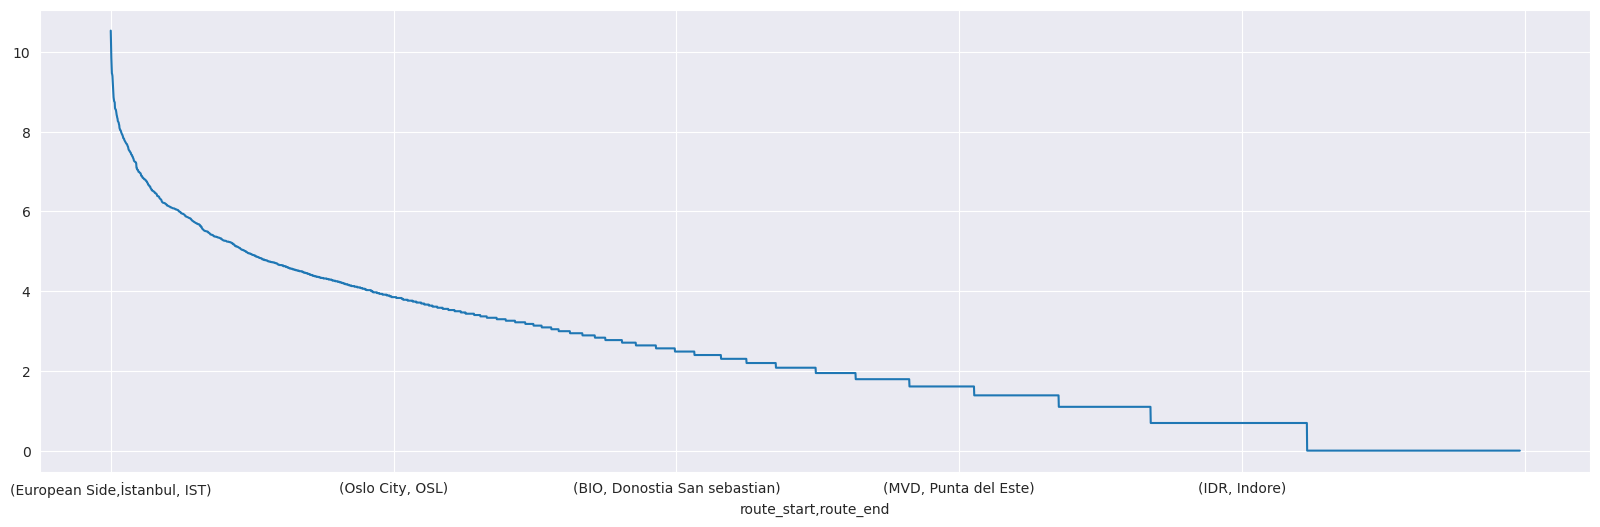

In [56]:
routes_count.plot(figsize=(20,6))
# routes_count


In [52]:
cumulative_count = routes_count.cumsum()
cumulative_count /= cumulative_count.iloc[-1]
cumulative_count = cumulative_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

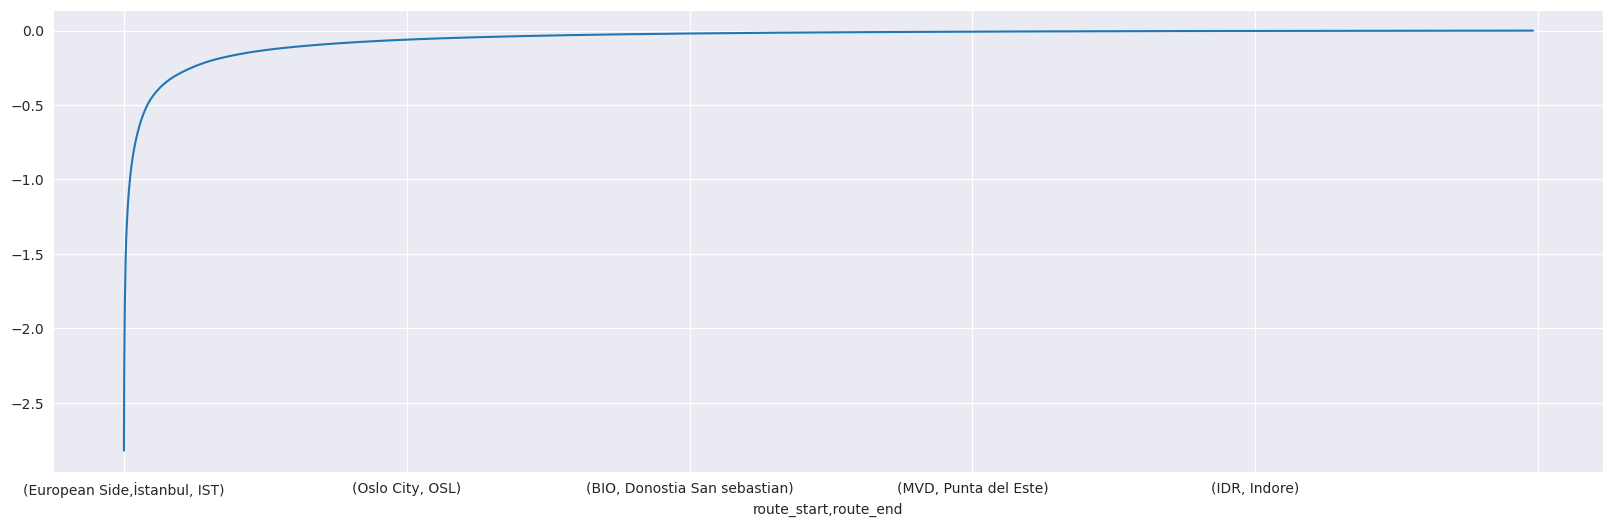

In [53]:

cumulative_count.plot(figsize=(20,6))

In [58]:
# df_routes = df.dropna(subset=['route_start', 'route_end'],how='all')
# len(df_routes)

631894

In [69]:
# # df_routes.set_index(['dispatch_id', 'route_end'], inplace=True)
# df_routes.iloc[:5,:]

,index,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,USH,Ushuaia
1,1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
2,2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
3,3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,USH,Ushuaia
4,4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,USH,Ushuaia


In [23]:
# cols = df.columns
# cols

Index(['dispatch_id', 'start_ltt_lp', 'start_lng_lp', 'end_ltt_lp',
       'end_lng_lp', 'route_start', 'route_end'],
      dtype='object')

In [24]:

# cols = [c.name for c in query.subquery().columns]
# result = [dict(zip(cols, row)) for row in df.to_numpy()]
# # result = [row for row in df.to_numpy()]
# result

[{'dispatch_id': 2979402,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.83495',
  'end_lng_lp': '-68.34771',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2615870,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2826367,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 1819243,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80264',
  'end_lng_lp': '-68.30629',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2035026,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.82094',
  'end_lng_lp': '-68.35159',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id'

In [28]:

# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum
# 
# chunk_size = 1000
# non_fpz_count = 0
# max_concurrent = 24
# 
# connection2 = sql_eng.connect()


In [25]:
# query1000= query.limit(1000)
# chunk_size=100
# raw_total_rows = 1000
# # df = pd.read_sql(query1000, sql_eng)
# # df
# for i,chunk in enumerate(tqdm(pd.read_sql(query1000,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     # for chunk in tqdm(pd.read_csv(csv_file_path, chunksize=chunk_size), total=total_lines//chunk_size +1):
#     # chunk.to_sql("price_training_labeled_2024_usd", sql_eng, if_exists='append', index=True)
#     dict_to_insert = [dict(zip(cols,row)) for row in chunk.to_numpy()]
#     insert_stmt = insert(label_archive).values(dict_to_insert)
#     session.execute(insert_stmt)
#     session.commit()



In [31]:
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
# 
#     return FPZQueryStatus.Success

# for i,chunk in enumerate(tqdm(pd.read_sql(query,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         # if i<500:
#         #     file_path = "../data/price_training_labeled_2024_usd1.csv"       
#         # else:
#         #     file_path = "../data/price_training_labeled_2024_usd2.csv"
#         file_path = "../data/price_training_labeled_2024_usd.csv"
#         with open(file_path, 'a') as f:
#             # chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#             chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#     except Exception as e:
#         print(f"\r {e}")
#         continue

Overall Progress:   0%|          | 0/1063 [00:00<?, ?it/s]

In [208]:
# df1 = df_lut.iloc[:10,:]
# df1
# len(df1)
# idx = df1.index.drop_duplicates(keep='first')
# df1[~df1.index.duplicated(keep='first')]
# df1

,,,,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,from_timezone_str,to_time_str,to_timezone_str,passenger_count,...,start_ltt,end_place_id,end_place,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end
start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,,,,,,,,,,,,,,,,,,,,,
37.61487,-122.38985,37.79414,-122.40779,123241,89521,2222284,1.0,1.740210e+09,2025-02-21 23:45,Pacific Standard Time,None,None,2.0,...,37.614871,1868.0,旧金山唐人街 美国加利福尼亚州旧金山旧金山唐人街,-122.407791,37.794138,1.0,Sedan,1,SFO,san francisco
24.07630,-110.36712,24.15539,-110.32272,186130,57630,2252856,1.0,1.709903e+09,2024-03-08 06:00,Mexican Pacific Standard Time,None,None,1.0,...,24.076300,35735.0,Malecon La Paz,-110.322718,24.155387,1.0,Sedan,1,LAP,La Paz
13.91326,100.60420,13.75957,100.54034,204703,38293,2261809,1.0,1.709262e+09,2024-03-01 10:00,Indochina Time,None,None,2.0,...,13.913260,38357.0,"酒店 104/7 Thanon Rang Nam, Khwaeng Thanon Phaya...",100.540340,13.759571,1.0,Sedan,1,DMK,市区中心
-37.82128,144.96533,-37.66901,144.84103,225395,585,2271309,1.0,NaN,"Mar 31, 2022 8:0",None,None,None,NaN,...,-37.821275,186.0,Melbourne Airport,144.841027,-37.669012,NaN,None,1,南墨尔本,MEL
40.73546,140.69041,40.29349,140.59228,282225,57783,2297841,2.0,1.725052e+09,2024-08-31 06:04,Asia/Tokyo,2024-09-01 09:50,Asia/Tokyo,3.0,...,40.735459,2029269.0,"End Location,",140.592282,40.293487,5.0,Minibus-8,1,None,None
18.76775,98.96401,18.78225,98.98766,310988,45507,2309705,2.0,1.704533e+09,2024-01-06 16:30,Indochina Time,2024-01-11 06:25,Indochina Time,2.0,...,18.767749,1681.0,Phor Liang Meun Terracotta Arts Hotel โรงแรมพ่...,98.987665,18.782251,1.0,Sedan,1,CNX,9-古城
26.08507,-80.11666,25.79375,-80.27585,315058,62025,2311454,1.0,1.705151e+09,2024-01-13 08:00,Eastern Standard Time,None,None,8.0,...,26.085070,10670.0,"Aeropuerto Miami 5600 NW 36th St, Miami, FL 33...",-80.275851,25.793748,5.0,Minibus-8,1,Fort Lauderdale,MIA
31.19348,121.35203,31.14340,121.65787,338118,36941,2321366,1.0,1.713989e+09,2024-04-25 04:00,China Standard Time,None,None,2.0,...,31.193481,22027.0,"Shanghai Disneyland Park 4MV5+945, Pudong, Sha...",121.657871,31.143397,2.0,Business Sedan,1,SHA,浦东机场圈
-34.81500,-58.53483,-34.60368,-58.38156,340666,2855,2322479,1.0,1.722413e+09,2024-07-31 05:00,Argentina Standard Time,None,None,1.0,...,-34.815004,47780.0,Buenos Aires,-58.381559,-34.603684,1.0,Sedan,1,EZE,Microcentro


10

In [28]:
# # df1 = df_lut.iloc[:10,:]
# # df1
# # len(df1)
# # idx = df1.index.drop_duplicates(keep='first')
# # df1[~df1.index.duplicated(keep='first')]
# # df1
# route_t = Table('route_lp', metadata, autoload_with=sql_eng)
# route_t = select(route_t)
# # noinspection PyUnboundLocalVariable
# connection = sql_eng.connect()


In [29]:
# s = route_t.limit(10)
# df = pd.read_sql(s,sql_eng)
# df

,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,,
1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,,
2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,,
3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,,
4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,,
5,2636003,-54.84330,-68.29580,-54.80900,-68.31558,,
6,2545121,-54.84330,-68.29580,-54.80740,-68.30604,,
7,1762309,-54.84330,-68.29580,-54.84171,-68.37298,,
8,2269213,-54.84330,-68.29580,-54.80733,-68.30539,,
9,2621659,-54.84330,-68.29580,-54.84183,-68.37259,,


In [30]:
# chunk_size = 10000

In [31]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum

In [91]:

# Create a dictionary with the data
data = {"cost": None, "profit": None}
data = {"cost": '30.09', "profit": '3.09'}

# Convert the dictionary to a JSON string
json_string = json.dumps(data)

# Format the JSON string using an f-string
formatted_string = f"User Data: {json_string}"

print(json_string)

{"cost": "30.09", "profit": "3.09"}


In [32]:
# csv_lp_route_result = '../data/lp_route_result.csv'


In [ ]:
# non_fpz_count = 0
# max_concurrent = 24
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
#     
#     return FPZQueryStatus.Success
# 
# for i,chunk in enumerate(tqdm(pd.read_sql(route_t,connection,index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Progress')):
#     chunk = chunk.astype({'start_ltt_lp': float, 'start_lng_lp': float, 'end_ltt_lp': float, 'end_lng_lp': float, 'route_start': str, 'route_end': str})
#     non_fpz_count_chunk = 0
#     # get_fixed_zone_chunk(chunk)
#     # for ind,r in chunk.iterrows():
#     #     result = get_one_fpz(r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#         
#     
#     with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
#         to_do_map = {} # list[futures.Future] = [] 
#         # for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
#         for ind,r in chunk.iterrows():
#             future = executor.submit(get_one_fpz, r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#             to_do_map[future] = ind
#         done_iter = as_completed(to_do_map)
#         done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
# 
#         for future in done_iter:
#             try:
#                 status = future.result()
#             except Exception as e:
#                 # print(f"Exception: {e}")
#                 continue
# 
#             if status == FPZQueryStatus.Success:
#                 ind = to_do_map[future]
#                 try:
#                     chunk.at[ind, 'route_start'] = fpz['route_start']
#                     chunk.at[ind, 'route_end'] = fpz['route_end']
#                 except KeyError as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#                 except Exception as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#             else:
#                 non_fpz_count_chunk += 1
#                 # print(f"\r non fzp chunk: {non_fzp_count_chunk}/{chunk_size}")
#                 continue
#         
#     non_fpz_count += non_fpz_count_chunk
#     scanned_row_number = (i+1)*chunk_size
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         with open(csv_lp_route_result, 'a') as f:
#             chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#         # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
#         # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#         print(f"\r Non_FZP count: {non_fpz_count}/{scanned_row_number}")
#     except Exception as e:
#         print(f"\r {e}, Non_FZP count: {non_fpz_count}/{scanned_row_number} ")
#         continue

Overall Progress:   0%|          | 0/107 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/10000 [00:00<?, ?it/s]

# inserted two new columns for fixed price zone start_zone and end_zone when creating sql table from csv file

In [ ]:
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN start_zone TEXT')
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN end_zone TEXT')
# start_zone_column = Column('start_zone', String)
# end_zone_column = Column('end_zone', String)
# add_column_op = AddColumn(start_zone_column, raw)


In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'


In [ ]:
# # Query the table in chunks
# query = session.query(raw)
# chunk_size =1000

In [ ]:
# batch_stmt = (
#     update(raw)  # 'raw' is your table object
#     .where(raw.c.dispatch_id == bindparam('b_dispatch_id'))
#     .values(
#         route_start=bindparam('route_start'),
#         route_end=bindparam('route_end')
#     )
# )
# print(batch_stmt)
# compiled = batch_stmt.compile()
# print(compiled.params)


In [ ]:
# result_csv = '../data/dispatch_fixed_zones_all.csv'
# for chunk in tqdm(pd.read_sql(query.statement, conn, index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Processing'):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     # print(chunk.dtypes)
#     route_list = []
#     for i,r in tqdm(chunk.iterrows(),total=chunk_size, desc='Chunk Processing', leave=False):
#         # l = [i, r['start_ltt'], r['start_lng'], r['end_ltt'], r['end_lng']]
#         # print(l)
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
# 
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             print(f"No Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 route_list.append((i, fix_price_zones['from'], fix_price_zones['to']))
#                 # fix_zone_routes_list.append(route)
#                 # chunk.at[i, 'route_start'] = fix_price_zones['from']
#                 # chunk.at[i, 'route_end'] = fix_price_zones['to']
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 # stmt = (
#                 #     update(raw)  # 'raw' is your table object
#                 #     .where(raw.c.dispatch_id == int(i))
#                 #     .values(
#                 #         route_start = fix_price_zones['from'],
#                 #         route_end = fix_price_zones['to']
#                 #     )
#                 # )
#                 # conn.execute(stmt)
#                 # conn.commit()
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#     
#     try:
#         pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv, mode='a', header=False)
#     except Exception as e:
#         print(f"csv: {e}")
#         continue
#     
#     # with sqlite_eng.begin() as conn:
#     #     conn.execute(
#     #         stmt, 
#     #         [
#     #             {
#     #                 'b_dispatch_id': i,
#     #                 'route_start': r['route_start'],
#     #                 'route_end': r['route_end']
#     #             }
#     #             for i,r in chunk.iterrows()
#     #         ],
#     #     )
#     #     conn.commit()


In [ ]:
# len(result)
# result[0]

In [ ]:

# with sql_eng.begin() as conn:
#     conn.execute(
#         batch_stmt, 
#         [
#             {
#                 'b_dispatch_id': i,
#                 'route_start': r['route_start'],
#                 'route_end': r['route_end']
#             }
#             for i,r in res.iterrows()
#         ],
#     )
#     conn.commit()


In [ ]:
# for chunk in pd.read_sql(query.statement, local_conn, chunksize=20):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     for i,r in chunk.iterrows():
#         # l = [r[0], r[1]['start_ltt'], r[1]['start_lng'], r[1]['end_ltt'], r[1]['end_lng']]
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
#         
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             j = j +1
#             print(f"{j} Not Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 # route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#                 # fix_zone_routes_list.append(route)
#                 chunk.at[i, 'route_start']
#                 
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 i = i +1
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#         
#         price_training_q = session.query(price_training_t).limit(500)
# fix_zone_routes_list = []


In [ ]:
# i = 0
# j = 0
# for pt in price_training_q:
#     # print('1')
#     # ride_samples.append(pt)
#     params = {
#         'from_lat': pt._mapping['start_ltt'],
#         'from_lng': pt._mapping['start_lng'],
#         'to_lat': pt._mapping['end_ltt'],
#         'to_lng': pt._mapping['end_lng'],
#         # 'from_utc':pt._mapping['from_utc'],
#     }
#     try:
#         response = requests.get(url=url, params=params)
#     except requests.exceptions.Timeout:
#         print('Timeout')
#         continue
#     except requests.exceptions.TooManyRedirects:
#         print('TooManyRedirects')
#         # Tell the user their URL was bad and try a different one
#     except requests.exceptions.RequestException as e:
#         print('RequestException, Catastrophic error!')
#         # continue
#         # catastrophic error. bail.
#         raise SystemExit(e)    
#         
#     except Exception as e:
#         print(f"request: {e}")
#         continue
#     # print('2')
#     try:
#         res = response.json()
#     except Exception as e:
#         print(f"json: {e}")
#         continue
#     # print('3')
#     try:
#         fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#     except KeyError as e:
#         j = j +1
#         print(f"{j} Not Fixed Price!")
#         continue
#     except IndexError as e:
#         print("IndexError for fix_price_zones")
#         continue
#     except Exception as e:
#         print(f"dict: {e}")
#         continue
#     # print('4')
#     if not isinstance(fix_price_zones,dict):
#         print(f"No fix price: {fix_price_zones}")
#     else:
#         try:
#             route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#             fix_zone_routes_list.append(route)
#             # ins = insert(fixed_zone_routes).values(
#             #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt._mapping['dispatch_id'])
#             i = i +1
#         except KeyError as e:
#             print("KeyError for route")
#             continue
# 
#         # print('5')
#         if i%50 == 0:
#             # connection.execute(ins)
#             df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
#             df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
#             fix_zone_routes_list = []
#             print(f"Created {i} records")
# 
#     # print('6')
# df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
# df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
# fix_zone_routes_list = []
# print(f"Created {i} records")
#     # print('6')
#     # print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # # print(pt._mapping['start_place'])
#     # print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # # print(pt._mapping['end_place']) 
#     # print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     # print("------------")

# Use ORM to retrieve records


In [ ]:
# sample_count = session.query(F.count(price_training_t.c.ride_id)).scalar()
# print(sample_count)
# 

In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'

In [ ]:

# params = {
#     'from_lat': 37.61911449999999,
#     'from_lng':-122.3816274,
#     'to_lat':37.3635295,
#     'to_lng':-121.9285932,
#     'from_utc':1727352000,
# }
# response = requests.get(url=url, params=params)
# response.json()


In [ ]:
# res = response.json()
# fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
# print(fix_price_zones)

In [ ]:
# ride_samples = []

In [ ]:
# pt = price_training_q.first()
# pt

In [ ]:
# params = {
#     'from_lat': (pt._mapping['start_ltt']),
#     'from_lng': (pt._mapping['start_lng']),
#     'to_lat': (pt._mapping['end_ltt']),
#     'to_lng': (pt._mapping['end_lng']),
#     # 'from_utc': int(pt._mapping['from_utc']),
# }
# params

# response = requests.get(url=url, params=params)
# res = response.json()
# res

In [ ]:
from sqlalchemy import String,Integer,insert

In [ ]:
# fix_zone_routes_list

In [ ]:
# price_training_q = session.query(price_training_t).limit(10)
# ride_samples = []
# for pt in price_training_q:
#     ride_samples.append(pt)
#     print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # print(pt._mapping['start_place'])
#     print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # print(pt._mapping['end_place']) 
#     print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     print("------------")



In [ ]:
# ride_samples[0]._mapping

In [ ]:
# df = pd.DataFrame(ride_samples)
# df

In [ ]:

# rides_q = session.query(price_training_t).limit(10)

In [ ]:

# for ride in rides_q:
#     print(ride)

In [ ]:
# rides_q = session.query(ride_ride_t).limit(10)
# for ride in rides_q:
#     print(ride)

In [ ]:
# print(price_training_t)

In [ ]:
# use core to retrieve records
# rp = connection.execute(price_training_t)
# for i, record in enumerate(rp):
#     print(i, record.ride_id)

In [ ]:
# results = rp.fetchall()
# results

In [ ]:
# df = pd.read_sql(price_training_t, engine)
# df

In [ ]:
# sqlite_eng = create_engine('sqlite:///../data/price_training_from_gbq_raw.db', echo=False)

In [ ]:
# df.to_sql('price_training_orlando_mpv5', sqlite_eng, if_exists='replace')

# Pandas Processing


## Traffic peak time exclusion
source https://www.quora.com/What-is-the-trickiest-time-of-the-day-to-drive-in-Orlando

In [ ]:
# from workalendar.usa import Florida

In [ ]:
# cal_orlando = Florida()


In [ ]:
# exclude_dates = [d[0] for d in cal_orlando.holidays(2024)]
# exclude_dates

In [ ]:
# from workalendar.usa import Florida 
# import numpy as np
# cal_florida = Florida()
# exclude_dates_str = [str(d[0]) for d in cal_florida.holidays(2024)]
# exclude_dates_str

In [ ]:
# exclude_dates = [d[0] for d in cal_florida.holidays(2024)]
# exclude_dates
# res = df['from_datetime_utc'].apply(lambda x: x in exclude_dates)

In [ ]:
# np.any(res.apply(lambda x: x in exclude_dates))
# res[0]=True
# res
# np.any(res)


In [ ]:
# from pricing.data.utils import validate_datetime_in_iso_format, validate_timezone_in_iana, get_timezone_abbreviation, fix_timezone

In [ ]:
# df_invalid_datetime = df[df.apply(lambda x: not validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_invalid_datetime

In [ ]:
# df_invalid_timezone = df[df.apply(lambda x: not validate_timezone_in_iana(x['from_timezone_str']), axis=1)]
# df_invalid_timezone

In [ ]:
#orlando_airport = pd.read_csv('../../data/orlando_all_output.csv')
#orlando_airport.head()
#orlando_airport.dtypes
#orlando_airport.to_sql('orlando_airport', sqlite_eng, if_exists='append')

In [ ]:
# df['from_timezone_fix_str'] = df.apply(lambda x: fix_timezone(x['from_timezone_str']), axis=1) 
# df

In [ ]:

# df_valid_datetime = df[df.apply(lambda x: validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_valid_timezone = df_valid_datetime[df_valid_datetime.apply(lambda x: validate_timezone_in_iana(x['from_timezone_fix_str']), axis=1)]
# df_valid_timezone


In [ ]:

# df_valid_timezone.loc[df_invalid_timezone.index, ['from_timezone_str', 'from_timezone_fix_str']]


In [ ]:
# from datetime import datetime
# import pytz
# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x['from_timezone_fix_str'])), axis=1)
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset


In [ ]:
# df_dt_str = df_valid_timezone['from_datetime_fix_str']
# df_valid_timezone['from_datetime_local'] = df_valid_timezone.apply(lambda x: (pd.to_datetime(x['from_datetime_fix_str']).to_datetime64()), axis=1)
# df_valid_timezone

In [ ]:
# df_valid_timezone.dtypes

In [ ]:

# df_valid_timezone['from_datetime_local_tz'] = df_valid_timezone.apply(lambda x: pytz.timezone(x.loc[:,'from_timezone_str']).localize(x.loc[:,'from_datetime_local']), axis=1)
# df_valid_timezone['from_timezone'] = df_valid_timezone.apply(lambda x: pytz.timezone(x['from_timezone_fix_str']), axis=1)
# df_valid_timezone


In [ ]:
# df_valid_timezone['from_datetime_tz'] = df_valid_timezone.apply(lambda x: x['from_timezone'].localize(x['from_datetime_local']), axis=1)
# df_valid_timezone
                                    # .apply(lambda x: x.localize(x.loc[:,'from_timezone_str']), axis=1))
# df_valid_timezone


# filtering out peak traffic time

In [ ]:
# peak_time_str = [('07:00:00', '09:00:00'), ('16:00:00', '19:00:00')]
# night_time_str = [('22:00:00', '6:00:00')]  # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am
# ind = []
# td = []
# for pt in peak_time_str:
#     ind.append(pd.DatetimeIndex(pt))
# ind
# for i in ind:
#     i[1]-i[0]

In [ ]:
# peak_time = []
# for pt in peak_time_str:
#     peak_time.append(pd.date_range(pt[0], pt[1], freq='h'))
# for pt in peak_time:
#     print(pt, pt.time)

In [ ]:
# peak_time_str

In [ ]:

# df_peak_traffic_time = df_valid_timezone[
#     df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1])
# ]
# df_peak_traffic_time

In [ ]:

# df_out_of_peak_traffic_time = df_valid_timezone[
#     ~ (df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1]))
# ]
# df_out_of_peak_traffic_time


In [ ]:

# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x.loc['timezone'])))
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset
# 

# filter out round trip (time reservation) with feature distance = 1 (m)

In [ ]:
# df_no_round_trip = df_valid_timezone[df_valid_timezone['distance'] > 1]

In [ ]:
# df_training = df_no_round_trip.loc[:,['ride_id', 'trip_type', 'trip_no', 'trip_count', 'ride_status', 'partner', 'fleet', 
#                 'start_place', 'end_place',
#                 'passenger_count', 'luggage_count',
#                 'dispatch_amount', 'dispatch_currency',
#                 'distance', 'duration', 'vehicle_class', 
#                 'from_datetime_tz']]
#  
# df_training['cent_price_per_km'] = df_training['dispatch_amount'] / df_training['distance']*100.0
# df_training

In [ ]:
# def average_cent_per_km(x):
#     x['average_cent_per_km'] = x['cent_price_per_km'].mean()
#     return x

In [ ]:
# def fleet_trip_no(x):
#     x['fleet_trip_count'] = len(x)
#     return x

In [ ]:
# df_fleet_statistics = df_training.loc[:, ['ride_id','fleet']]
# df_fleet_statistics

In [ ]:

# df_fleet_trip_no = df_fleet_statistics.groupby('fleet').aggregate([len])
# df_fleet_trip_no.sort_values(by=('ride_id', 'len'), ascending=False, inplace=True)
# df_fleet_trip_no


In [ ]:
# df_big_fleets = df_fleet_trip_no[df_fleet_trip_no[('ride_id','len')] >100]
# df_big_fleets

In [ ]:
# df_big_fleet_data = []
# for f in df_big_fleets.index:
#     print(f)
#     df_big_fleet_data.append(df_training[df_training['fleet'] == f])

In [ ]:
# df_big_fleet_data[0]

In [ ]:
# df_big_fleet_data[1]

In [ ]:
# df_big_fleet_data[2]

In [ ]:

# # df_training['average_cent_per_km'] = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis


In [ ]:

# df_training

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()